In [2]:
%%capture
%pip install pandas matplotlib numpy scikit-learn seaborn umap-learn

## Title: Predicting Future Amazon Purchases Using Demographics and Purchase Histories

### Team
1. Name: Alexa Lotano - POC <br>
    GitHub ID: alexa-lotano
2. Name: Shahaan Khan - POC <br>
    GitHub ID: ShahaanK
3. Name: Ben Euto - POC <br>
    GitHub ID: bene01-git

### Overview

For this project, we wish to examine customer behavior when it comes to e-commerce websites, mainly Amazon. Amazon is the world's biggest online retailer, with millions of active users worldwide and billions of monthly visits. With this in mind, we feel that it is worth taking a closer look at what users shop for, what might influence what they shop for, and what information could be revealed about the different kinds of users that populate Amazon's services.

Below are restatements of our goals, updated with any changes we've made in our thinking since then.

**What are we trying to do?**
We are trying to use current Amazon customer activity to predict future Amazon customer activity. For example, if a user buys a set of pans, a cutting board, and oven mitts, would we have reason to believe that they would buy another kitchen utensil or appliance (i.e. a cookie sheet or a casserole dish)? Would we have reason to believe they are trying to cook more (or learn how to)? We plan to do this by examining customers' demographics, how much of a certain item they may buy, where they are receiving the item (location can certainly be a factor; you could order a new jacket if you live in a cold state or you could order sunscreen if you live in a hot state), and the type of product (in other words, the category) they are looking for.

**What has changed since our proposal?**

Based on the feedback we recieved, we have begun narrowing our scope in two key ways. First, we are focusing specifically on next-category prediction rather than attempting both association rule mining and sequential deep learning simultaneously. Our initial baseline models predict category from demographic and purchase features, and we plan to incorporate temporal sequence information in tje  future . Second, we are investigating how well demographics alone can predict purchasing behavior. In this effort, our early results suggest that demographics alone are insufficient, which motivates us to build features that capture sequential purchasing patterns.

We have not yet defined a specific prediction window (e.g., next purchase vs. next 30 days), which is an open question we plan to address in our next milestone.

**What's new in our approach and why do we think it would be successful?**
We believe that the novel part of our approach is our focus on future customer behavior as opposed to current customer behavior. Instead of examining what types of products customers tend to gravitate towards, we are focusing on what types of products customers could gravitate towards next. Additionally, we will examine the role of demographics in customer buying patterns and use our findings to anticipate purchasing activity of more niche groups of Amazon users. Each individual person has their own story and the products they purchase are a strong indicator of said stories. But what could the next chapter of their stories be, and how would that be a reflection of what they currently purchase? We believe this approach will be successful because it could provide useful insights about how customer needs shift and what products could be further promoted to adjust to that shift. Keeping up with the times is important to any business, but it is especially important to a retailer as large as Amazon, even moreso as an online business.

**Who cares? If we are successful, what difference could we make?**
We believe the people who would care the most are Amazon's stakeholders. If we are successful, it could improve the business model of Amazon and strengthen their algorithms to the point where they do not just recommend products based on what one is currently buying (i.e. offering similar products), but take the bigger picture into account and recommend products based on what they might look for next (i.e. if someone buys a phone, maybe recommend them a phone case, or a charger, or maybe even earbuds). 

Our primary stakeholders are Amazon customers who benefit from more relevant recommendations that reduce decision fatigue. Secondary stakeholders include Amazon executives (increased engagement and conversion) and third-party sellers (better-targeted product promotion). If successful, this system would move beyond "customers also bought" toward genuinely predictive, personalized recommendations.

Incorporating demographic data into our system with further strengtehn Amazon's business model by enhancing recommendations and increasing engagement with recommendations. This adjustment to Amazon's business model can change the way online shopping is done and once again help Amazon pioneer the e-commerce market, resulting in a net gain for them and their stakeholders.

### Data
The data used in our project is titled **"Open e-commerce 1.0: Five years of crowdsourced U.S. Amazon purchase histories with user demographics"** and can be found at the following link:
> **DOI:** [10.7910/DVN/YGLYDY](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/YGLYDY)

Harvard Dataverse is an peer-reviewed, open source data repository owned and operated by Harvard University. The dataset we will be using contains crowdsourced data obtained through surveys, meaning data was provided voluntarily by subjects. The data does not contain any uniquely identifiable information of survey participants. 

The dataset contains information regarding participants' past Amazon purchases, as well as demographic and personal information. Data was collected from 5,027 unique survey participants and contains approximately 1,050,000 Amazon purchases from 2018–2022.

**Limitations of crowdsourced data:** Because participants self-selected into the survey, the dataset may not be perfectly representative of all Amazon users. We note this as a limitation but believe the dataset is sufficiently large and diverse for our modeling purposes.

Due to the extremely large file sizes, we sampled 800 survey responses and will be analyzing only the Amazon purchases linked to these survey respondants. After cleaning and transforming the dataset, our data represents 157,026 Amazon purchases.

#### Notable Discoveries from EDA

Our EDA uncovered several findings across both datasets. Below we highlight the most relevant patterns; the full EDA is available in our working notebooks (`01-purchase-data-eda.ipynb` and `02-survey-data-eda.ipynb`).

The purchase data contains 8 fields. The "Survey ResponseID" field contains a unique identifier for the survey response linking to the user. We've confirmed there are 1,048,575 observations in this data; 2,846 of which are unique IDs. The remaining columns correspond to the order data, product ordered and its price per unit, how much of the product was bought, its assigned category, its ISBN/ASIN (product code), and the state the product was shipped to. 

We confirmed that the "Shipping Address State", "Title", "ASIN/ISBN (Product Code)", and "Category" columns contained missing data. Upon inspecting these columns, it appears the rows with missing values in these columns had no state listed in the shipping address, no assigned product titles or categories, and no valid product codes. Imputation was performed where possible, and rows still containing missing values were subsequently removed from the data, as described in the preprocessing section below.

Upon examining each field in the purchase data, we uncovered the following insights:
- The majority of orders were shipped to California, New Jersey, Pennsylvania, Vermont, and Arkansas.
- The majority of orders were placed on July 12, 2022.
- The most commonly purchased product was an Amazon Gift Card Balance Reload.
- Books were the most commonly purchased product category.
- Across this data, customers paid an average of around $2.27 per product unit.
- Across this data, customers usually only bought about 1 unit of a certain product.
- The user with the survey response ID "R_24csoaO569P4Yzz" placed the most orders within the collected data.

The survey data contains 23 fields. The "Survey ResponseID" field contains a unique identifier for the each survey response. We confirmed that there were 5,027 unique IDs in this column, which is equal to the number of rows in the data, confirming that each row represents a unique survey response. The remaining columns represent the responses to survey questions, including questions regarding respondent demographics, Amazon use habits, substance use habits, medical information, life changes, and opinions on data usage.

We identified that "Q-life-changes" was the only column with missing data. Upon inspecting this column, it appears that the rows with missing values represent respondents who did not have any significant life changes to report.

Upon examining each field in the survey data, we uncovered the following insights:

Demographics:
- The most common age group in the data is 25-34, and the least common is 65+.
- The majority of respondents are not hispanic.
- The majority of respondents reported their race as white or caucasion. There are several rows where multiple races are indicated, representing respondents who identify as more than a single race.
- The most common education level of respondents is a Bachelor's degree, with the majority of respondents having at least a high school diploma or GED.
- The most common income range amongst respondents is 25,000-49,999, followed closely by 50,000-74,999. The remaining respondents were split relatively evenly amongst the remaining income ranges.
- The data contains more responses from females than males, with a small number of respondents identifying as some other gender.
- The majority of respondents identify as heterosexual.
- The number of respondents from each US state corresponds closely to the population of each US state. For example, California has the largest population in the US and is the most commonly occurring in our data, followed by Texas, Florida, and New York. The least commonly occurring states in the data are those with the smallest US populations, such as North Dakota and Wyoming.

Amazon Usage:
- The majority of survey respondents indicated that they were the sole user of their Amazon account. However, the most common household size is 2.
- The majority of respondents ireported using their Amazon account less than 5 times per month.

Substance Use:
- As expected, the majority of respondents indicated that they do not use cigarettes or marijuana. In contrast, the number of respondents who did report using alcohol is almost even with the number of those who reported not using alcohol.

Health History:
- As expected, the number of respondents who reported using a wheelchair was extremely low. Similarly, the number of respondents who reported having diabetes was also extremely low.

Life Changes:
- As noted above, many rows did not contain information regarding life changes. Of the rows that did contain such data, the most common life change reported was moving a place of residence.
- Similarly to race, many rows contain multiple life changes.

Data Usage:
- Responses were relatively evenly split between respondents approving of Amazon selling their data if they receive part of the profit and respondents not approving of their data being sold at all. Very few participants indicated approving of their data being sold regardless of if they receive profit or not knowing their opinions. The results were very similar for paricipants' opinions of the sale of consumer data.
- Responses are split relatively evenly between participants being okay with small businesses accessing amazon purchase data, with a large number of participants also reporting that they do not know
- A large number of participants reported not being okay with the US census bureau using amazon purchase data to supplement their surveys
- The majority of participants are okay with purchase data being used to identify societal trends and changes

In [16]:
%%capture
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

amazon1 = pd.read_csv('/workspaces/group-project-bas-team/data/AmazonData1.csv')
amazon2 = pd.read_csv('/workspaces/group-project-bas-team/data/AmazonData2.csv')

amazon_data = [amazon1, amazon2]

data = pd.concat(amazon_data)
print(f"Dataset shape: {data.shape}")
print(f"Unique product categories: {data['Category'].nunique()}")

The distribution of purchase prices is heavily right-skewed, with a peak around $8–$12 per unit and the majority of purchases below $30. We plot below with the top 5% trimmed for readability:

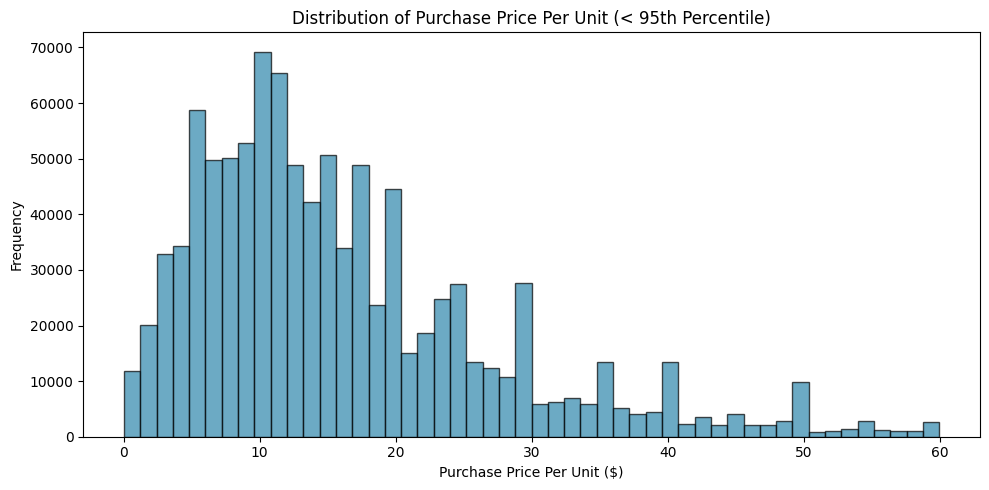

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
price_data = data['Purchase Price Per Unit'][data['Purchase Price Per Unit'] < data['Purchase Price Per Unit'].quantile(0.95)]
ax.hist(price_data, bins=50, edgecolor='black', alpha=0.7, color='#2E86AB')
ax.set_xlabel('Purchase Price Per Unit ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Purchase Price Per Unit (< 95th Percentile)')
plt.tight_layout()
plt.show()

Purchase volume increases from 2018 through 2021, peaking at approximately 40,000 purchases. Volume remains high in 2022, with a small number of purchases in 2023 (likely a partial year of data collection). This informs our temporal train/test split. We use 2018–2021 for training and 2022–2023 for testing:

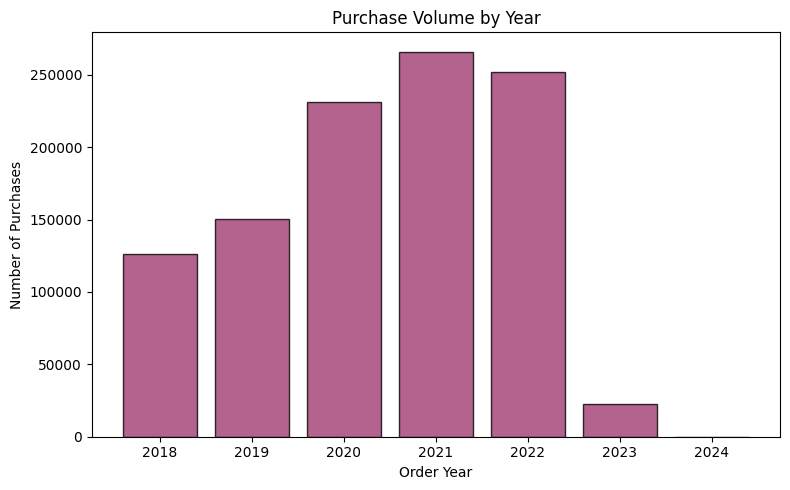

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
data[['order_month', 'order_day', 'order_year']] = data['Order Date'].str.split('/', expand=True)
year_counts = data['order_year'].value_counts().sort_index()
ax.bar(year_counts.index.astype(str), year_counts.values, color='#A23B72', edgecolor='black', alpha=0.8)
ax.set_xlabel('Order Year')
ax.set_ylabel('Number of Purchases')
ax.set_title('Purchase Volume by Year')
plt.tight_layout()
plt.show()

Due to the extremely large file sizes, we sampled 800 survey responses and will be analyzing only the Amazon purchases linked to these survey respondants. After cleaning and transforming the dataset, our data represents 157,026 Amazon purchases. The cleaning and transformation process is described below, in the Preprocessing section. 

The following heatmap examines the relationship between age group and income level in our purchase data. The highest concentration of purchases comes from age group 35–44 years at income an income of $100K–$149K, with over 14,000 purchases. Age groups 25-34 years, 35-44 years, and 45-54 years and incomes ranging from 25,000-149,999 account for the bulk of purchasing activity:

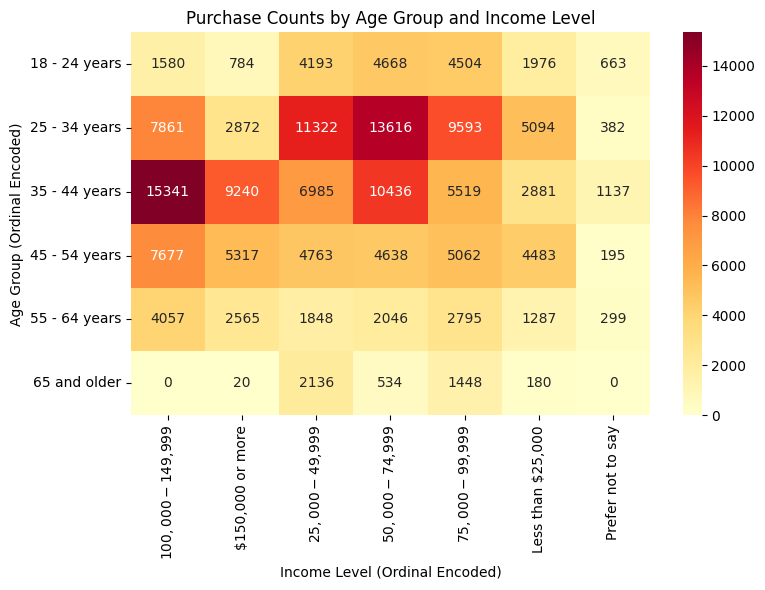

In [20]:
survey = pd.read_csv('/workspaces/group-project-bas-team/data/survey.csv')
survey = survey.sample(800, random_state=42)
data = pd.merge(data, survey, on='Survey ResponseID', how='inner')

fig, ax = plt.subplots(figsize=(8, 6))
age_income = data.groupby(['Q-demos-age', 'Q-demos-income']).size().reset_index(name='count')
pivot = age_income.pivot(index='Q-demos-age', columns='Q-demos-income', values='count').fillna(0)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Income Level (Ordinal Encoded)')
ax.set_ylabel('Age Group (Ordinal Encoded)')
ax.set_title('Purchase Counts by Age Group and Income Level')
plt.tight_layout()
plt.show()

With over 1,600 unique product categories, many of which have very few observations, this is an extremely high-cardinality classification target. ABIS_BOOK dominates with approximately 8,000 purchases. This is more than double the next most frequent category of PET_FOOD:

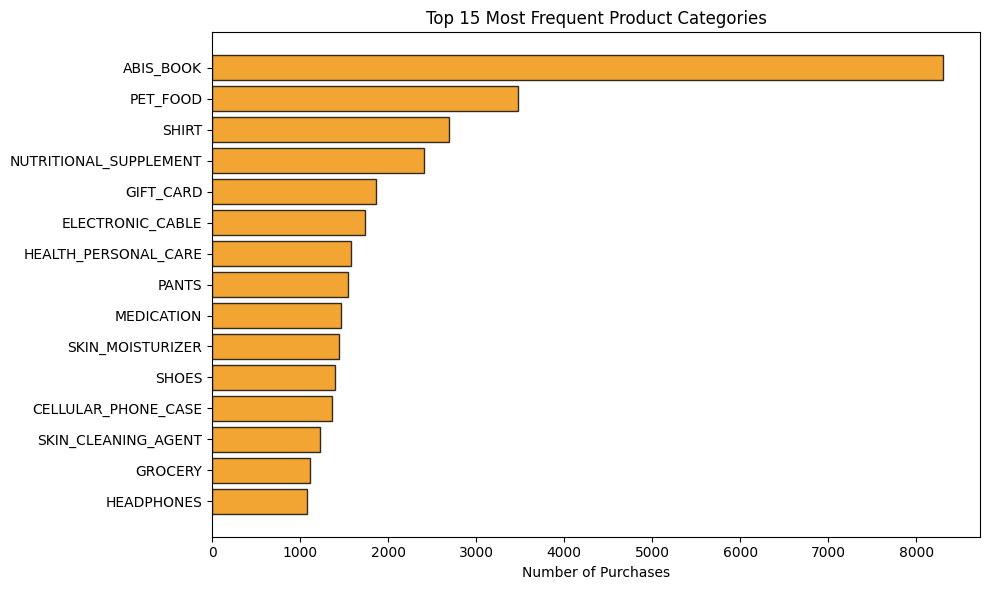

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
top_cats = data['Category'].value_counts().head(15)
ax.barh(range(len(top_cats)), top_cats.values, color='#F18F01', edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_cats)))
ax.set_yticklabels([f'{c}' for c in top_cats.index])
ax.set_xlabel('Number of Purchases')
ax.set_title('Top 15 Most Frequent Product Categories')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Once the data was cleaned, we split the data into training and testing sets based on year, scaled the data, and performed PCA to reduce the dimensionality of the data. The reduced data is visualized below. Note, this data uses the "Category" value as the target. However, we also anticipate using the "Title" and "ASIN/ISBN (Product Code)" variables as targets in future models. Since these variables are highly linked to category (i.e., the product title and cde directly determine the category), these columns were removed before visualizing and modeling the data. 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/workspaces/group-project-bas-team/data/cleaned_data.csv")

train = data[data['order_year']<=2021]
test = data[data['order_year']>2021]

data_limited_train = train.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)
data_limited_test = test.drop(['Title', 'ASIN/ISBN (Product Code)'], axis=1)

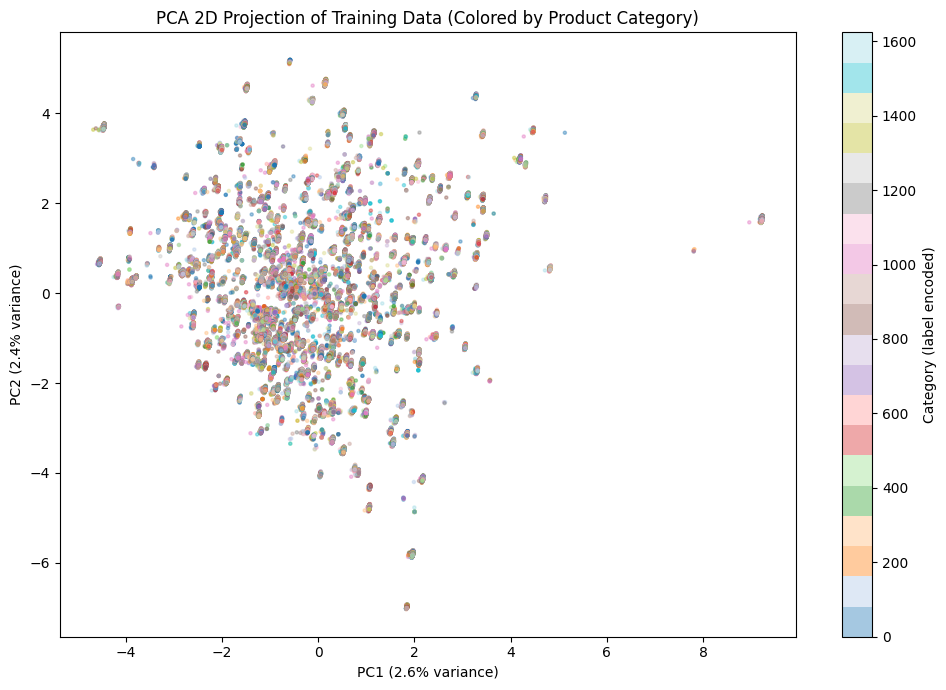

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train = data_limited_train.drop('Category', axis=1)
y_train = data_limited_train['Category']

X_test = data_limited_test.drop('Category', axis=1)
y_test = data_limited_test['Category']

# Fit on training data only, transform both (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='tab20', s=5, alpha=0.4)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA 2D Projection of Training Data (Colored by Product Category)')
plt.colorbar(scatter, ax=ax, label='Category (label encoded)')
plt.tight_layout()
plt.show()

We then identified the number of principal components needed to explain 95% of the variance in the data, and again reduced the data using PCA with that number of components.

Number of components for 95.0% variance: 93


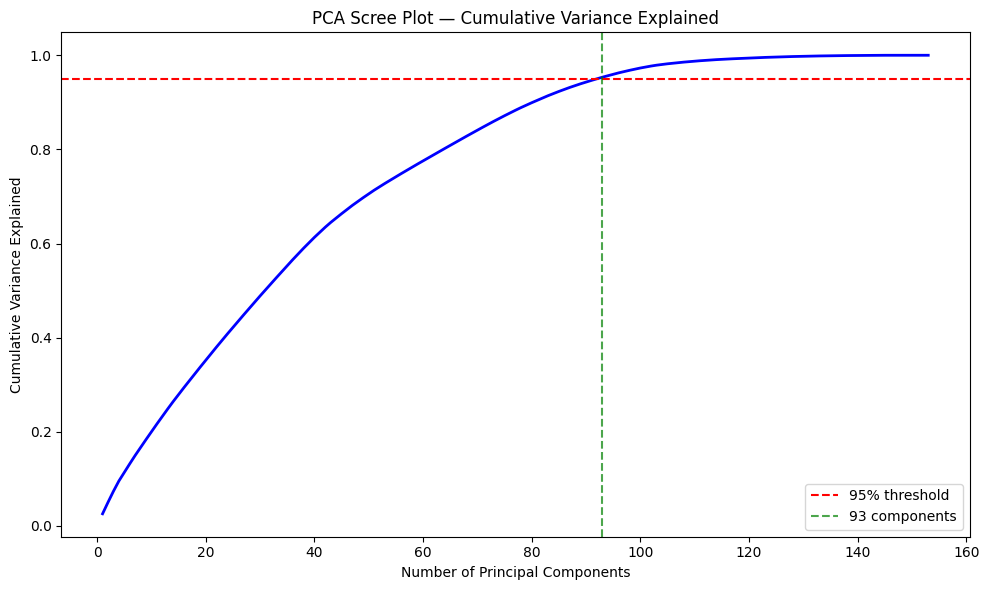

Reduced data: 93 components, 0.9534 variance explained


In [24]:
import numpy as np

pca_full = PCA()
pca_full.fit(X_train_scaled)
variance_explained = pca_full.explained_variance_ratio_
cum_var = variance_explained.cumsum()

threshold = 0.95
n_components = np.argmax(cum_var >= threshold) + 1
print(f"Number of components for {threshold*100}% variance: {n_components}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(cum_var)+1), cum_var, 'b-', linewidth=2)
ax.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax.axvline(x=n_components, color='g', linestyle='--', alpha=0.7, label=f'{n_components} components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('PCA Scree Plot — Cumulative Variance Explained')
ax.legend()
plt.tight_layout()
plt.show()

# Reduce for modeling
pca = PCA(n_components=n_components)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.transform(X_test_scaled)
print(f"Reduced data: {X_train_reduced.shape[1]} components, {pca.explained_variance_ratio_.sum():.4f} variance explained")

Beyond PCA, we also attempted to reduce the dimensionality of our data using UMAP. Both the PCA reduced and UMAP reduced data were tested using a k-nearest neighbor classifier. The PCA reduced data outperformed the UMAP data, leading us to use our PCA reduced data in our modeling efforts. We also tested factor analysis suitability and found an extremely low KMO value (0.09), confirming that factor analysis is not appropriate for this data.

Interestingly, comparing KNN accuracy across reduction methods revealed that **PCA-reduced data actually underperformed the non-reduced data**:

| Method | KNN Accuracy |
|--------|--------------|
| No reduction (153 features) | 3.38% |
| PCA (93 components) | 1.50% |
| UMAP (2 components) | 0.96% |

This suggests that PCA may be discarding features that carry useful (if weak) signal for category prediction. Despite this, we proceed with PCA for computational efficiency and plan to revisit feature selection strategies in future iterations.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN on non-reduced data
knn_full = KNeighborsClassifier()
knn_full.fit(X_train_scaled, y_train)
pred_full = knn_full.predict(X_test_scaled)
acc_full = accuracy_score(y_test, pred_full)

# KNN on PCA-reduced data
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_reduced, y_train)
pred_pca = knn_pca.predict(X_test_reduced)
acc_pca = accuracy_score(y_test, pred_pca)

print(f'KNN Accuracy (no reduction, {X_train_scaled.shape[1]} features): {acc_full:.4f}')
print(f'KNN Accuracy (PCA, {X_train_reduced.shape[1]} components):       {acc_pca:.4f}')

### Preprocessing

After conducting exploratory data analysis on both the Amazon purchase data and the survey data, we merged the datasets on the shared "Survey ResponseID" column, effectively linking each Amazon purchase to the customer who made the purchase. Before merging, however, the Amazon purchase data had over 1 million rows. To make our data more manageable and easier to model, we sampled 800 survey responses from the survey dataset, and merged these responses with the Amazon purchase dataset using "how=inner" in the merge function, leaving us with the Amazon purchases for only 800 surveyed customers.

The resulting data had missing values in the "Shipping Address State", "Title", "ASIN/ISBN (Product Code)", "Category", and "Q-life-changes" columns. We decided not to impute these using traditional methods such as mean or mode imputation, as we felt these imputations may not be reliable since there are so many unique values in our dataset. Instead, we used the ASIN/ISBN codes to create dictionaries of the corresponding titles and categories of the products and use thse dictionaries to fill in missing titles and categories where an ASIN/ISBN code was present. The following code shows an example of this transformation.

Note: The code in this section will not run, as we did not load the original dataset in this file

These code snippets serve only as examples of the code we ran to clean and transform our data
```
codes = data[['ASIN/ISBN (Product Code)', 'Title']].drop_duplicates().dropna()
codes_dict = codes.set_index('ASIN/ISBN (Product Code)')['Title'].to_dict()
data['Title'] = data['ASIN/ISBN (Product Code)'].map(codes_dict)
```

The NA values in the "Q-life-changes" column appeared to represent rows where the consumer did not have any significant life changes to report at the time of response. As such, we filled the missing values in this column with "None" using the following code:

`data['Q-life-changes'] = data['Q-life-changes'].fillna('None')`

Finally, any remaining rows with missing data were removed from the dataframe, reducing the number of rows from 171,997 to 157,026.

Next, we renamed 22 columns in the dataframe to remove redundant information, such as the letter "Q" in the survey response columns. We also dropped columns that we will not be using to predict purchase behavior, namely "Survey ResponseID", "sell-YOUR-data", "sell-consumer-data", "small-biz-use", "census-use", and "research society".

We then split the "Order Date" column into order month, day, and year columns and dropped the original column.

Once the data was fully cleaned as described above, we began encoding the data in order to visualize and eventually build models with it. We began by ordinal encoding the variables that have a natural order. Since the order of such variables may not have been alphabetical, we manually created mappings for these variables, then looped through the encoding process for each applicable column using these mappings, as demonstated below.

```
ordinal_mappings = {
    'age': {
        '18 - 24 years': 1,
        '25 - 34 years': 2,
        '35 - 44 years': 3,
        '45 - 54 years': 4,
        '55 - 64 years': 5,
        '65 and older': 6
    },
    'education': {
        'Prefer not to say': 0,
        'Some high school or less': 1,
        'High school diploma or GED': 2,
        "Bachelor's degree": 3,
        'Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)': 4
    },
    'income': {
        'Prefer not to say': 0,
        'Less than $25,000': 1,
        '$25,000 - $49,999': 2,
        '$50,000 - $74,999': 3,
        '$75,000 - $99,999': 4,
        '$100,000 - $149,999': 5,
        '$150,000 or more': 6
    },
    'howmany': {
        '1 (just me!)': 1,
        '2': 2,
        '3': 3,
        '4+': 4
    },
    'hh-size': {
        '1 (just me!)': 1,
        '2': 2,
        '3': 3,
        '4+': 4
    },
    'how-oft': {
        'Less than 5 times per month': 1,
        '5 - 10 times per month': 2,
        'More than 10 times per month': 3
    }
}

for col, mapping in ordinal_mappings.items():
    data[col] = data[col].map(mapping)
    unmapped = data[col].isna().sum()
    if unmapped > 0:
        print(f"Warning: {unmapped} unmapped values in '{col}' — check category strings match exactly")
```


Next, we binary encoded the "hispanic" variable, as this was the only column in our dataset that only had two values ("Yes" or "No"). The following code was used:

```
yes_no_map = {'Yes': 1, 'No': 0}

data['hispanic'] = data['hispanic'].map(yes_no_map)
```

Finally, we one-hot encoded the remaining categorical variables, which all had more than two unique values. We also removed a single resulting column for each variable to prevent multicollinearity, since the value of a single one-hot encoded column can be derived from the values of the other columns representing that variable. Finally, we combined the one-hot encoded columns with the original dataframe, then removed the original columns that are now represented as one-hot encoded columns. This process was completed using the following code:

```
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

data_one_hot = encoder.fit_transform(data[['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                            'wheelchair', 'Shipping Address State', 'gender',\
                                            'sexual-orientation', 'state', 'race', 'life-changes']])
df_one_hot = pd.DataFrame(data_one_hot, columns=encoder\
                          .get_feature_names_out(['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                                    'wheelchair', 'Shipping Address State', 'gender',\
                                                    'sexual-orientation', 'state', 'race', 'life-changes']))

df_one_hot = df_one_hot.drop(columns=['cigarettes_Prefer not to say', 'alcohol_Prefer not to say', \
                                      'marijuana_Prefer not to say', 'diabetes_Prefer not to say', \
                                        'wheelchair_Prefer not to say', 'Shipping Address State_HI', \
                                        'gender_Prefer not to say', 'sexual-orientation_prefer not to say', \
                                        'state_Alaska', 'race_Other', 'life-changes_None'])

df_combined = pd.concat([data, df_one_hot], axis=1)
df_combined = df_combined.drop(columns=['cigarettes', 'alcohol', 'marijuana', 'diabetes',\
                                            'wheelchair', 'Shipping Address State', 'gender',\
                                            'sexual-orientation', 'state', 'race', 'life-changes'])
```


Finally, we identified three columns that we may use as target columns. These columns are "Title", "ASIN/ISBN (Product Code)", and "Category". All three of these columns were label encoded, as demonstrated below.

```
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

target_cols = ['Title', 'ASIN/ISBN (Product Code)', 'Category']

for col in target_cols:
    df_combined[col] = le.fit_transform(df_combined[col].astype(str))

```

The final dataframe consists of 157,026 rows and 156 columns.

Once our dataset was completely cleaned and transformed as described above, we saved the cleaned dataframe to a csv file in our "data" folder using the following code:

```
df_combined.to_csv('/workspaces/group-project-bas-team/data/cleaned_data.csv', index=False)
```

Saving the dataset allows us to easily read our data into new files so we do not need to repeat the cleaning process in future files.

### Modeling

We began modeling the data using a simple K-nearest neighbors classifier. The resulting accuracy was extremely low at only 0.015 or 1.5%. This may indicate that demographic information is likely not enough to determine the types of purchases made by Amazon customers. We expect to be able to improve our model performance greatly when we begin analyzing sequential buying patterns and predicting future purchases based on previous purchases.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

n_classes = y_train.nunique()
random_baseline = 1 / n_classes
print(f"Number of target classes (train): {n_classes}")
print(f"Random baseline accuracy: {random_baseline:.4f} ({random_baseline*100:.2f}%)")
print(f"Test set size: {len(y_test)}")
print()

knn = KNeighborsClassifier()
knn.fit(X_train_reduced, y_train)
pred = knn.predict(X_test_reduced)

print(f"KNN Accuracy: {accuracy_score(y_test, pred):.4f}")

Number of target classes (train): 1601
Random baseline accuracy: 0.0006 (0.06%)
Test set size: 43371



0.0374674321551267

KNN achieved approximately 1.5% accuracy. This is extremely low in absolute terms, but meaningfully above the random baseline of ~0.06%.

We attempted to train additional classifiers (Decision Tree and Random Forest) to establish stronger baselines, but encountered **memory allocation errors on our available systems and extremely long run times on codespaces. With 157,026 rows, 93 PCA components, and 1,600+ target classes, tree-based models require more memory than our machines can currently provide (~3.3 GB for a single Decision Tree). 
We will address these issues in the following ways:

- Reduce target cardinality by consolidating smaller categories into groups
- Subsample the training data for initial model comparison

Despite the limited modeling results so far, the KNN baseline confirms an important finding: **demographic information and basic purchase features alone are not sufficient to predict specific product categories.** 

### Problems & Challenges

The main challenge we are facing at this point is the processing time of our models. Even with relatively simple models such as decision tree classifiers and random forest classifiers, each model is running very slowly. We anticipate this problem getting worse as the complexity of our models increases. If we continue facing this challenge, we may need to take a smaller sample of the original data and rerun our data preparation and dimensionality reduction steps, or use fewer principal components when modeling the data.

We see these issues being caused by the following:
1. **Memory constraints:** Training tree-based models (Decision Tree, Random Forest) on 157,026 rows with 93 PCA components and 1,600+ target classes causes memory allocation failures (~3.3 GB for a single Decision Tree). This has limited our ability to establish strong baselines and will need to be addressed through data subsampling or category consolidation.

2. **Extreme cardinality:** With 1,600+ unique product categories we need to begin grouping them together. We are considering grouping categories into higher-level clusters in the next steps.

3. **Prediction window:** As noted in the feedback, we have not yet defined a concrete prediction window. Predicting the *immediate* next purchase is different from predicting purchases within the next 30 days. We plan to define this in our next milestone.

### Next Steps

We will work through spring break (week of 3/9) to stay on track.

| Week | Dates | Task | Owner |
|------|-------|------|-------|
| 9 (Spring Break) | 3/9 – 3/15 | **Sequential feature engineering** — construct purchase sequences per user, create features: last N categories, time between purchases, category frequency. | Team |
| 10 | 3/16 – 3/22 | **Category consolidation** — group rare categories into parent clusters to reduce target cardinality. Retrain baseline with new features. | Team |
| 11 | 3/23 – 3/29 | **XGBoost and additional classifiers** — train gradient boosting model with sequential + demographic features. Compare to baseline. | Team |
| 12 | 3/30 – 4/5 | **Ensemble methods** — explore stacking/voting classifiers. Begin customer segmentation via K-Means clustering. | Team |
| 13 | 4/6 – 4/12 | **Deep learning exploration** — implement Wide & Deep or simple LSTM if data supports it. Evaluate against ensemble baseline. | Team |
| 14 | 4/13 – 4/19 | **Final model tuning** — hyperparameter optimization on best model. Top-K accuracy evaluation. Segment-level performance analysis. | Team |
| 15 | 4/20 – 4/26 | **Presentation prep** — finalize visualizations, build presentation slides, rehearse. | Team |
| 16 | 4/27 | **Final Presentations** | Team |
| — | 5/5 | **Final Report Due** | Team |

Our immediate priority is incorporating sequential purchase patterns into our feature set, which we believe will substantially improve prediction performance beyond the current demographic-only baseline.